## Week 8 — SFGP Matérn-1.5 + qLogNEI + Rank-Based Interior Penalty (5D)

This notebook fits a GP surrogate on cumulative Week 8 data (all-negative outputs) and proposes
the next ingredient formulation using **qLogNEI** with feasibility bounds and **rank-based interior penalty**.

**Why rank-based IP?** All F6 outputs are negative, so multiplicative IP (mean × weight) would
_invert_ the ranking — penalising interior points instead of boundary ones. Rank-based scoring
is sign-invariant.

**Feasibility:** x4 (milk) ≥ 0.10, other ingredients ≥ 0.01.

In [1]:
import numpy as np
import torch
import copy
import re
import warnings
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import ScaleKernel, MaternKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan

warnings.filterwarnings('ignore', message='The input matches the stored training data')
warnings.filterwarnings('ignore', category=RuntimeWarning)

### Hyperparameter Documentation

| # | Parameter | Value | Rationale |
|---|-----------|-------|-----------|
| 1 | **Kernel** | Matérn ν=1.5 | Once-differentiable (C¹); rougher than ν=2.5, wider posterior uncertainty in gaps |
| 2 | **ARD** | True (5 lengthscales) | One per ingredient dimension |
| 3 | **ℓ init** | 0.5 | Broad initial uncertainty |
| 4 | **Output scale init** | 1.0 | Matches standardised Var ≈ 1.0 |
| 5 | **Noise init** | 0.2 | 20% of standardised Var(y); aggressive exploration init |
| 6 | **Noise floor** | 1e-2 (GreaterThan) | Prevents boundary-trap exploitation |
| 7 | **Outcome transform** | Standardize(m=1) (default) | Auto z-score; no manual transform needed |
| 8 | **MLL restarts** | 15 | Guards against local optima |
| 9 | **Acquisition** | qLogNoisyExpectedImprovement | Log-space, noisy variant |
| 10 | **q (batch)** | 4 | Candidate diversity |
| 11 | **raw_samples** | 3000 | Sobol initial points |
| 12 | **num_restarts** | 50 | L-BFGS starting points |
| 13 | **Selection** | Distance-based | mean ≥ median, farthest from data |
| 14 | **Bounds** | Feasibility-constrained | x4 ≥ 0.10, others ≥ 0.01 |
| 15 | **Clamping** | [0.0, 0.999999] | Submission format compliance |

In [2]:
# ── Constants ──
N_RESTARTS     = 15
STEEPNESS      = 1.0
FLOOR          = 0.01
DIM            = 5
Q              = 4
MC_SAMPLES     = 512
ACQ_RESTARTS   = 50
RAW_SAMPLES    = 3000
GRID_RES       = 80

ingredient_names = ['flour', 'sugar', 'eggs', 'butter', 'milk']

# Feasibility bounds: x4 (milk) ≥ 0.10, others ≥ 0.01
BOUNDS = torch.tensor(
    [[0.01, 0.01, 0.01, 0.01, 0.10],
     [1.00, 1.00, 1.00, 1.00, 1.00]],
    dtype=torch.double,
)

print("Constants configured:")
print(f"  DIM={DIM}, Q={Q}, N_RESTARTS={N_RESTARTS}")
print(f"  MC_SAMPLES={MC_SAMPLES}, ACQ_RESTARTS={ACQ_RESTARTS}, RAW_SAMPLES={RAW_SAMPLES}")
print(f"  STEEPNESS={STEEPNESS}, FLOOR={FLOOR}")
print(f"  Ingredients: {ingredient_names}")
print(f"  Bounds lower: {BOUNDS[0].tolist()}")
print(f"  Bounds upper: {BOUNDS[1].tolist()}")

Constants configured:
  DIM=5, Q=4, N_RESTARTS=15
  MC_SAMPLES=512, ACQ_RESTARTS=50, RAW_SAMPLES=3000
  STEEPNESS=1.0, FLOOR=0.01
  Ingredients: ['flour', 'sugar', 'eggs', 'butter', 'milk']
  Bounds lower: [0.01, 0.01, 0.01, 0.01, 0.1]
  Bounds upper: [1.0, 1.0, 1.0, 1.0, 1.0]


In [3]:
# ── Data Loading (Week 8) ──
X_raw = np.load('../../data/f6/updated_inputs - Week 8.npy')
y_raw = np.load('../../data/f6/updated_outputs - Week 8.npy')

# Validate shapes and ranges
assert X_raw.shape == (28, 5), f"Expected (28, 5), got {X_raw.shape}"
assert y_raw.shape == (28,), f"Expected (28,), got {y_raw.shape}"
assert X_raw.min() >= 0.0 and X_raw.max() <= 1.0, "Inputs out of [0, 1]"
assert (y_raw < 0).all(), "Expected all-negative outputs"

best_idx = int(y_raw.argmax())
print(f"Week 8 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"Input range:  [{X_raw.min():.6f}, {X_raw.max():.6f}]")
print(f"Output range: [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Output variance: {y_raw.var():.6f}")
print(f"Best observed value: {y_raw[best_idx]:.6f} at index #{best_idx}")
print(f"Best observed point: {X_raw[best_idx]}")

# Per-ingredient ranges
print(f"\nPer-ingredient ranges:")
for i, name in enumerate(ingredient_names):
    lo, hi = X_raw[:, i].min(), X_raw[:, i].max()
    print(f"  x{i} ({name:>6s}): [{lo:.6f}, {hi:.6f}]")

Week 8 Data: 28 samples, 5 dimensions
Input range:  [0.000000, 1.000000]
Output range: [-2.571170, -0.205600]
Output variance: 0.334838
Best observed value: -0.205600 at index #26
Best observed point: [0.446858 0.469936 0.644334 0.729109 0.003508]

Per-ingredient ranges:
  x0 ( flour): [0.021735, 0.957740]
  x1 ( sugar): [0.000000, 0.931871]
  x2 (  eggs): [0.016523, 0.999999]
  x3 (butter): [0.045613, 1.000000]
  x4 (  milk): [0.000000, 0.892819]


### GP Surrogate — SFGP Matérn-1.5 ARD (15-Restart MLL)

- **Kernel**: `ScaleKernel(MaternKernel(nu=1.5, ard_num_dims=5))` — rougher than ν=2.5, wider uncertainty in gaps
- **Noise floor**: `GreaterThan(1e-2)` — prevents exact interpolation & boundary exploitation
- **Outcome transform**: Default `Standardize(m=1)` — auto z-scores Y internally; posterior auto-untransforms
- **MLL scoring**: Uses `model.train_targets` (standardised) NOT `Y_train.squeeze(-1)` (raw)
- **Post-fit assertion**: Fitted noise must remain ≥ 1e-2

In [4]:
# ── GP Training with 15-Restart MLL ──
# Convert raw data to torch tensors — NO manual log1p or z-score transform.
# Standardize(m=1) (BoTorch default) handles z-scoring internally.
X_train = torch.tensor(X_raw, dtype=torch.double)
Y_train = torch.tensor(y_raw, dtype=torch.double).unsqueeze(-1)  # (28, 1)

print(f"X_train shape: {tuple(X_train.shape)}, Y_train shape: {tuple(Y_train.shape)}")
print(f"Y_train range: [{Y_train.min().item():.6f}, {Y_train.max().item():.6f}]")

best_loss = float('inf')
best_model = None

print(f"\n{'Restart':>8} {'Neg MLL':>12}")
print("-" * 22)

for seed in range(N_RESTARTS):
    torch.manual_seed(seed)

    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(1e-2))
    covar = ScaleKernel(MaternKernel(nu=1.5, ard_num_dims=DIM))

    # Do NOT pass outcome_transform — default Standardize(m=1) applies automatically.
    # This z-scores Y internally; posterior auto-untransforms to original space.
    model = SingleTaskGP(X_train, Y_train, covar_module=covar, likelihood=likelihood)

    # Initialise hyperparameters (exploration-promoting)
    model.covar_module.base_kernel.lengthscale = 0.5
    model.likelihood.noise = 0.2  # 20% of standardised Var(y)≈1.0
    model.covar_module.outputscale = 1.0

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    model.eval()
    likelihood.eval()
    with torch.no_grad():
        output = model(X_train)
        # Score using model.train_targets (standardised), NOT Y_train.squeeze(-1) (raw)
        loss = -mll(output, model.train_targets).item()

    print(f"{seed:>8d} {loss:>12.4f}")

    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

# Report fitted hyperparameters
ls = best_model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
os_val = best_model.covar_module.outputscale.detach().cpu().item()
noise = best_model.likelihood.noise.detach().cpu().item()

print(f"\n{'='*50}")
print(f"Best restart neg MLL: {best_loss:.6f}")
print(f"{'='*50}")
print(f"Fitted Hyperparameters:")
for i, l in enumerate(ls):
    print(f"  ℓ_{i+1} ({ingredient_names[i]:>6s}) = {l:.6f}")
print(f"  σ²_f (output scale) = {os_val:.6f}")
print(f"  σ²_n (noise)        = {noise:.6f}")
assert noise >= 1e-2, f"Fitted noise {noise} below floor 1e-2!"
print(f"  ✓ Noise ≥ 1e-2 constraint satisfied")

X_train shape: (28, 5), Y_train shape: (28, 1)
Y_train range: [-2.571170, -0.205600]

 Restart      Neg MLL
----------------------
       0      -1.0503
       1      -1.0503
       2      -1.0503
       3      -1.0503
       4      -1.0503
       5      -1.0503
       6      -1.0503
       7      -1.0503
       8      -1.0503
       9      -1.0503
      10      -1.0503
      11      -1.0503
      12      -1.0503
      13      -1.0503
      14      -1.0503

Best restart neg MLL: -1.050264
Fitted Hyperparameters:
  ℓ_1 ( flour) = 1.102703
  ℓ_2 ( sugar) = 1.418806
  ℓ_3 (  eggs) = 1.763580
  ℓ_4 (butter) = 1.323010
  ℓ_5 (  milk) = 2.255918
  σ²_f (output scale) = 1.885157
  σ²_n (noise)        = 0.010000
  ✓ Noise ≥ 1e-2 constraint satisfied


In [5]:
# ── qLogNEI Acquisition (q=4) + Distance-Based Selection ──
best_model.eval()

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
nei = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train,
    sampler=sampler,
    prune_baseline=True,
)

candidates, acq_value = optimize_acqf(
    acq_function=nei,
    bounds=BOUNDS,
    q=Q,
    num_restarts=ACQ_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

# Clamp to [0, 0.999999] for submission format
candidates = torch.clamp(candidates, 0.0, 0.999999)

# Evaluate posterior at candidates — Standardize(m=1) auto-untransforms to original space.
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_means = posterior.mean.squeeze(-1).cpu().numpy()  # (4,) — original space, all negative

# Compute min-distance from each candidate to training data
dists = torch.cdist(candidates, X_train).min(dim=1).values  # (4,)

# Distance-based selection: filter to mean ≥ median, pick farthest from data
median_mean = np.median(pred_means)
above_median = pred_means >= median_mean

print(f"=== qLogNEI Acquisition Results (Week 8, q={Q}) ===")
print(f"Bounds: lower={BOUNDS[0].tolist()}, upper={BOUNDS[1].tolist()}")
print(f"{'Cand':>5} {'Coords':>55} {'Mean(orig)':>12} {'MinDist':>8} {'Above Med?':>11}")
print("-" * 100)
for i in range(candidates.shape[0]):
    coords = candidates[i].cpu().numpy()
    coord_str = "[" + ", ".join(f"{v:.6f}" for v in coords) + "]"
    flag = "✓" if above_median[i] else " "
    print(f"{i+1:>5} {coord_str:>55} {pred_means[i]:>12.6f} {dists[i].item():>8.4f} {flag:>11}")

# Validate all candidate x4 values ≥ 0.10
x4_values = candidates[:, 4].cpu().numpy()
assert all(v >= 0.10 for v in x4_values), f"Some x4 values below 0.10: {x4_values}"
print(f"\n✓ All candidate x4 (milk) values ≥ 0.10: {[f'{v:.4f}' for v in x4_values]}")

# Select: among above-median, pick farthest from any existing observation
above_median_indices = np.where(above_median)[0]
if len(above_median_indices) == 0:
    best_nei_idx = int(np.argmax(pred_means))
    selection_reason = "fallback — highest predicted mean (none above median)"
else:
    above_median_dists = dists[above_median_indices].cpu().numpy()
    best_nei_idx = above_median_indices[np.argmax(above_median_dists)]
    selection_reason = "farthest from data among above-median"

nei_point = candidates[best_nei_idx].cpu().numpy()

print(f"\nMedian posterior mean: {median_mean:.6f}")
print(f"Above-median candidates: {list(above_median_indices + 1)}")
print(f"\n→ NEI selected candidate #{best_nei_idx + 1} ({selection_reason})")
print(f"  Coordinates: [{', '.join(f'{v:.6f}' for v in nei_point)}]")
print(f"  Posterior mean (orig): {pred_means[best_nei_idx]:.6f}")
print(f"  Min-distance to data:  {dists[best_nei_idx].item():.4f}")
print(f"  Acquisition value: {acq_value.item():.6f}")
print(f"  x4 (milk) = {nei_point[4]:.6f} {'✓ ≥ 0.10' if nei_point[4] >= 0.10 else '✗ BELOW 0.10!'}")

=== qLogNEI Acquisition Results (Week 8, q=4) ===
Bounds: lower=[0.01, 0.01, 0.01, 0.01, 0.1], upper=[1.0, 1.0, 1.0, 1.0, 1.0]
 Cand                                                  Coords   Mean(orig)  MinDist  Above Med?
----------------------------------------------------------------------------------------------------
    1      [0.254320, 0.154047, 0.999999, 0.999999, 0.621349]    -1.225309   0.6549            
    2      [0.401612, 0.395069, 0.638364, 0.792528, 0.100000]    -0.300480   0.1314           ✓
    3      [0.402330, 0.330813, 0.573610, 0.733655, 0.100000]    -0.311843   0.1511            
    4      [0.477082, 0.396610, 0.549288, 0.732679, 0.100000]    -0.277913   0.1356           ✓

✓ All candidate x4 (milk) values ≥ 0.10: ['0.6213', '0.1000', '0.1000', '0.1000']

Median posterior mean: -0.306161
Above-median candidates: [np.int64(2), np.int64(4)]

→ NEI selected candidate #4 (farthest from data among above-median)
  Coordinates: [0.477082, 0.396610, 0.549288, 0.732679

Top-2 important dims: x0 (flour), x3 (butter) (ℓ=1.1027, 1.3230)
Fixed dims: x1 (sugar)=0.3966, x2 (eggs)=0.5493, x4 (milk)=0.1000


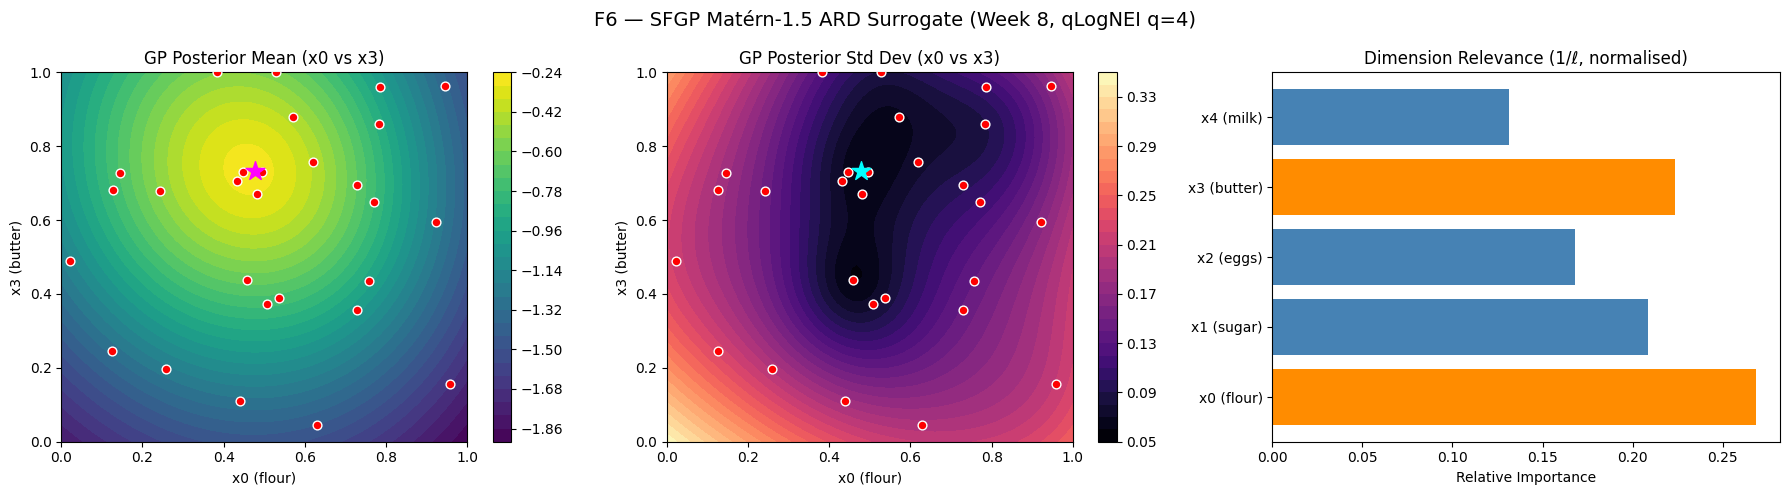

In [6]:
# ── Surrogate Visualisation (3-Panel) ──

# Identify top-2 important dims (shortest lengthscales = most important)
sorted_dims = np.argsort(ls)
top2 = sorted_dims[:2]
fix_dims = sorted_dims[2:]

print(f"Top-2 important dims: x{top2[0]} ({ingredient_names[top2[0]]}), "
      f"x{top2[1]} ({ingredient_names[top2[1]]}) "
      f"(ℓ={ls[top2[0]]:.4f}, {ls[top2[1]]:.4f})")
print(f"Fixed dims: " + ", ".join(
    f"x{d} ({ingredient_names[d]})={nei_point[d]:.4f}" for d in fix_dims))

# Build grid over top-2 dims
g0 = np.linspace(0, 1, GRID_RES)
g1 = np.linspace(0, 1, GRID_RES)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.tile(nei_point, (GRID_RES * GRID_RES, 1))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()

# GP posterior on grid — Standardize(m=1) auto-untransforms
grid_tensor = torch.tensor(grid_pts, dtype=torch.double)
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(grid_tensor)
    grid_mu = posterior.mean.squeeze(-1).cpu().numpy().reshape(GRID_RES, GRID_RES)
    grid_sigma = posterior.variance.sqrt().squeeze(-1).cpu().numpy().reshape(GRID_RES, GRID_RES)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean (original scale)
c1 = axes[0].contourf(G0, G1, grid_mu, levels=30, cmap="viridis")
axes[0].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes[0].scatter(nei_point[top2[0]], nei_point[top2[1]], c="magenta", marker="*", s=200, zorder=6)
axes[0].set_title(f"GP Posterior Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]} ({ingredient_names[top2[0]]})")
axes[0].set_ylabel(f"x{top2[1]} ({ingredient_names[top2[1]]})")
fig.colorbar(c1, ax=axes[0])

# Panel 2: Std
c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap="magma")
axes[1].scatter(X_raw[:, top2[0]], X_raw[:, top2[1]], c="red", edgecolors="white", s=40, zorder=5)
axes[1].scatter(nei_point[top2[0]], nei_point[top2[1]], c="cyan", marker="*", s=200, zorder=6)
axes[1].set_title(f"GP Posterior Std Dev (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]} ({ingredient_names[top2[0]]})")
axes[1].set_ylabel(f"x{top2[1]} ({ingredient_names[top2[1]]})")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Dimension relevance (1/ℓ normalised)
inv_ls = 1.0 / ls
inv_ls_norm = inv_ls / inv_ls.sum()
colors = ['steelblue'] * DIM
for d in top2:
    colors[d] = 'darkorange'
axes[2].barh(range(DIM), inv_ls_norm, color=colors)
axes[2].set_yticks(range(DIM))
axes[2].set_yticklabels([f"x{j} ({ingredient_names[j]})" for j in range(DIM)])
axes[2].set_title("Dimension Relevance (1/ℓ, normalised)")
axes[2].set_xlabel("Relative Importance")

plt.suptitle("F6 — SFGP Matérn-1.5 ARD Surrogate (Week 8, qLogNEI q=4)", fontsize=14)
plt.tight_layout()
plt.show()

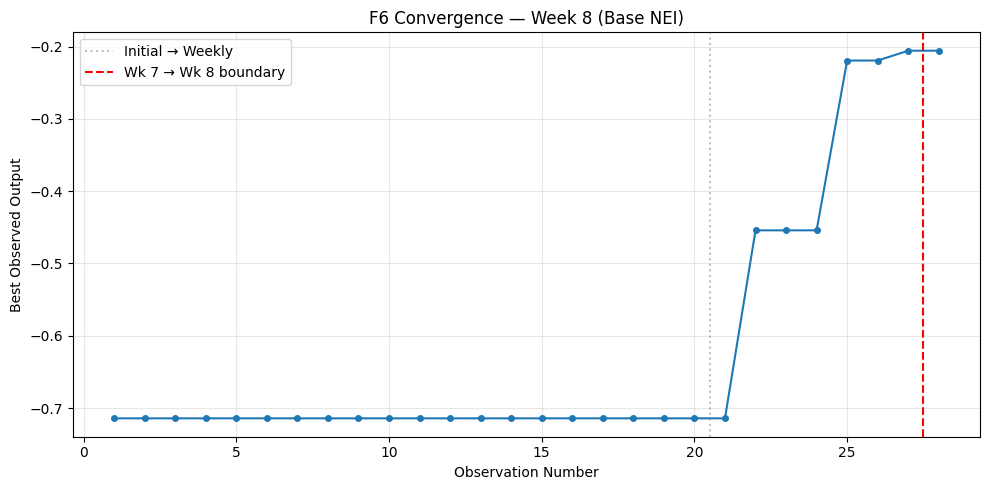

Running best at initial end (sample 20): -0.714265
Running best at Week 7 end (sample 27):  -0.205600
Running best at Week 8 end (sample 28):  -0.205600


In [7]:
# ── Convergence Plot (Base NEI) ──
running_best = np.maximum.accumulate(y_raw)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_raw) + 1), running_best, marker="o", markersize=4, linewidth=1.5)
plt.axvline(x=20.5, color="gray", linestyle=":", alpha=0.5, label="Initial → Weekly")
plt.axvline(x=27.5, color="red", linestyle="--", label="Wk 7 → Wk 8 boundary")
plt.xlabel("Observation Number")
plt.ylabel("Best Observed Output")
plt.title("F6 Convergence — Week 8 (Base NEI)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at initial end (sample 20): {running_best[19]:.6f}")
print(f"Running best at Week 7 end (sample 27):  {running_best[26]:.6f}")
print(f"Running best at Week 8 end (sample 28):  {running_best[27]:.6f}")

In [8]:
# ── Base NEI Submission Query ──
submission_point_nei = np.clip(nei_point, 0.0, 0.999999)
query_nei = "-".join(f"{v:.6f}" for v in submission_point_nei)

print("=" * 60)
print("WEEK 8 SUBMISSION QUERY — F6 (Base NEI)")
print("=" * 60)
print(f"\n  {query_nei}\n")
print("=" * 60)

# Validation
parts = query_nei.split("-")
assert len(parts) == 5, f"Expected 5 dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 0.999999, f"Value {v} out of bounds"
assert re.match(r'^(0\.\d{6}-){4}0\.\d{6}$', query_nei), f"Format mismatch: {query_nei}"
assert float(parts[4]) >= 0.10, f"x4 (milk) = {parts[4]} below feasibility bound 0.10!"
print("✓ Format validated")
print(f"✓ x4 (milk) = {parts[4]} ≥ 0.10")

# Per-ingredient breakdown
print(f"\nPer-ingredient breakdown:")
for i, (name, val) in enumerate(zip(ingredient_names, submission_point_nei)):
    bound = '≥ 0.10' if i == 4 else '≥ 0.01'
    status = '✓' if (val >= 0.10 if i == 4 else val >= 0.01) else '✗'
    print(f"  x{i} ({name:>6s}) = {val:.6f}  {status} {bound}")

WEEK 8 SUBMISSION QUERY — F6 (Base NEI)

  0.477082-0.396610-0.549288-0.732679-0.100000

✓ Format validated
✓ x4 (milk) = 0.100000 ≥ 0.10

Per-ingredient breakdown:
  x0 ( flour) = 0.477082  ✓ ≥ 0.01
  x1 ( sugar) = 0.396610  ✓ ≥ 0.01
  x2 (  eggs) = 0.549288  ✓ ≥ 0.01
  x3 (butter) = 0.732679  ✓ ≥ 0.01
  x4 (  milk) = 0.100000  ✓ ≥ 0.10


### Interior Penalty Re-Scoring (Rank-Based)

Apply a soft interior penalty to discourage boundary-hugging candidates.

$$w(\mathbf{x}) = \text{FLOOR} + (1 - \text{FLOOR}) \cdot \prod_{i=1}^{D} \sin(\pi x_i)^{2 \cdot \text{STEEPNESS}}$$

Because F6 outputs are **all negative**, multiplicative scoring (`mean × w`) would *invert* the ranking (lower w × negative mean → less negative → appears better). **Rank-based** scoring is sign-invariant:

1. `rank_mean = argsort(argsort(pred_means)) + 1`  — higher mean = higher rank  
2. `rank_weight = argsort(argsort(interior_weight)) + 1`  — more interior = higher rank  
3. `combined_score = rank_mean + rank_weight`  — additive, range [2, 2Q]

| Hyperparameter | Value | Rationale |
|----------------|-------|-----------|
| STEEPNESS      | 1.0   | Strong boundary decay; rank-based scoring makes magnitude irrelevant |
| FLOOR          | 0.01  | Prevents zero-weight degeneracy at exact corners |

In [9]:
# ── Interior Penalty: Compute Weights ──
cands_np = candidates.cpu().numpy()  # (4, 5)

# w(x) = FLOOR + (1 - FLOOR) * ∏ᵢ sin(πxᵢ)^(2·STEEPNESS)
interior_weight = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * cands_np) ** (2 * STEEPNESS), axis=1
)  # (4,)

assert interior_weight.shape == (Q,)
assert np.all(interior_weight >= FLOOR)
assert np.all(interior_weight <= 1.0)

print("=== Interior Penalty Weights ===")
print(f"STEEPNESS = {STEEPNESS}, FLOOR = {FLOOR}")
print(f"{'Cand':>5} {'w(x)':>10} {'Label':>12}")
print("-" * 30)
for i in range(len(interior_weight)):
    label = "interior" if interior_weight[i] >= 0.5 else "boundary"
    print(f"{i+1:>5} {interior_weight[i]:>10.6f} {label:>12}")
print(f"\nMin weight: {interior_weight.min():.6f}, Max weight: {interior_weight.max():.6f}")

=== Interior Penalty Weights ===
STEEPNESS = 1.0, FLOOR = 0.01
 Cand       w(x)        Label
------------------------------
    1   0.010000     boundary
    2   0.033249     boundary
    3   0.043345     boundary
    4   0.055708     boundary

Min weight: 0.010000, Max weight: 0.055708


In [10]:
# ── Interior Penalty: Rank-Based Re-Scoring & Selection ──
rank_mean   = np.argsort(np.argsort(pred_means)) + 1      # (4,) ranks 1–4
rank_weight = np.argsort(np.argsort(interior_weight)) + 1  # (4,) ranks 1–4
combined_score = rank_mean + rank_weight                    # range [2, 8]

# Median filter on combined score
score_median = np.median(combined_score)
above_score = combined_score >= score_median
above_score_indices = np.where(above_score)[0]

# Distance-based selection among above-median candidates
if len(above_score_indices) == 0:
    best_ip_idx = int(np.argmax(combined_score))
    ip_reason = "fallback — highest combined score (none above median)"
else:
    above_score_dists = dists[above_score_indices].cpu().numpy()
    best_ip_idx = above_score_indices[np.argmax(above_score_dists)]
    ip_reason = "farthest from data among above-median (rank-filtered)"

ip_point = candidates[best_ip_idx].cpu().numpy()

print("=== Rank-Based Re-Scoring (Interior Penalty) ===")
print(f"{'Cand':>5} {'pred_mean':>12} {'R(mean)':>8} {'w(x)':>10} {'R(w)':>6} {'Score':>6} {'Sel':>4}")
print("-" * 60)
for i in range(len(pred_means)):
    sel = " ◄" if i == best_ip_idx else "  "
    print(f"{i+1:>5} {pred_means[i]:>12.6f} {rank_mean[i]:>8d} "
          f"{interior_weight[i]:>10.6f} {rank_weight[i]:>6d} "
          f"{combined_score[i]:>6d} {sel}")

print(f"\nScore median: {score_median:.1f}")
print(f"Above-median candidates: {list(above_score_indices + 1)}")
print(f"\n→ IP selected candidate #{best_ip_idx + 1} ({ip_reason})")
print(f"  Coordinates: [{', '.join(f'{v:.6f}' for v in ip_point)}]")
print(f"  Posterior mean: {pred_means[best_ip_idx]:.6f}")
print(f"  Interior weight: {interior_weight[best_ip_idx]:.6f}")
print(f"  Combined score: {combined_score[best_ip_idx]} / {2 * Q}")
assert ip_point[4] >= 0.10, f"x4 (milk) = {ip_point[4]:.6f} below 0.10!"
print(f"  ✓ x4 (milk) = {ip_point[4]:.6f} ≥ 0.10")

=== Rank-Based Re-Scoring (Interior Penalty) ===
 Cand    pred_mean  R(mean)       w(x)   R(w)  Score  Sel
------------------------------------------------------------
    1    -1.225309        1   0.010000      1      2   
    2    -0.300480        3   0.033249      2      5   
    3    -0.311843        2   0.043345      3      5  ◄
    4    -0.277913        4   0.055708      4      8   

Score median: 5.0
Above-median candidates: [np.int64(2), np.int64(3), np.int64(4)]

→ IP selected candidate #3 (farthest from data among above-median (rank-filtered))
  Coordinates: [0.402330, 0.330813, 0.573610, 0.733655, 0.100000]
  Posterior mean: -0.311843
  Interior weight: 0.043345
  Combined score: 5 / 8
  ✓ x4 (milk) = 0.100000 ≥ 0.10


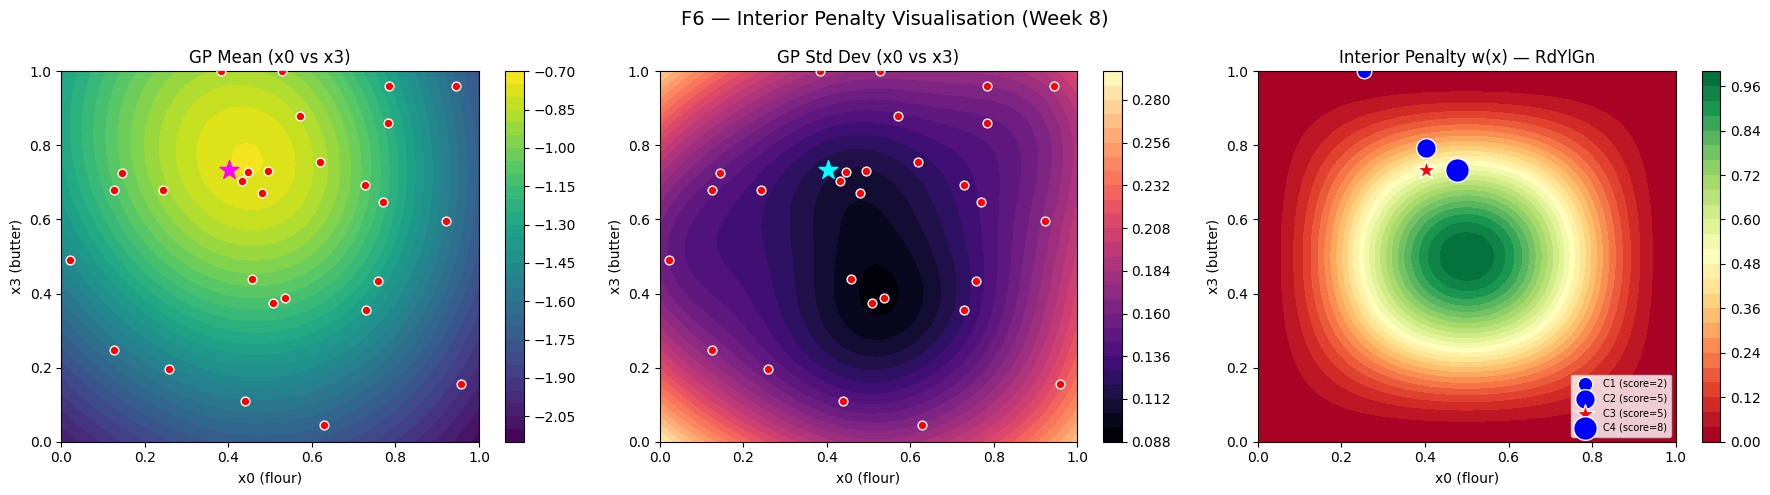

In [11]:
# ── Interior Penalty: 3-Panel Visualisation ──
inv_ls_plot = 1.0 / ls
top2_ip = np.argsort(inv_ls_plot)[-2:][::-1]
dim_a, dim_b = top2_ip[0], top2_ip[1]

grid = np.linspace(0, 1, GRID_RES)
xx, yy = np.meshgrid(grid, grid)
base = np.full((GRID_RES * GRID_RES, DIM), 0.5)
base[:, dim_a] = xx.ravel()
base[:, dim_b] = yy.ravel()

grid_t = torch.tensor(base, dtype=torch.double)
best_model.eval()
with torch.no_grad():
    post_grid = best_model.posterior(grid_t)
    mean_grid = post_grid.mean.squeeze(-1).cpu().numpy().reshape(GRID_RES, GRID_RES)
    std_grid  = post_grid.variance.squeeze(-1).sqrt().cpu().numpy().reshape(GRID_RES, GRID_RES)

# Penalty surface on the grid
w_grid = FLOOR + (1 - FLOOR) * np.prod(
    np.sin(np.pi * base) ** (2 * STEEPNESS), axis=1
).reshape(GRID_RES, GRID_RES)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean
c1 = axes[0].contourf(xx, yy, mean_grid, levels=30, cmap="viridis")
axes[0].scatter(X_raw[:, dim_a], X_raw[:, dim_b], c="red", edgecolors="white", s=40, zorder=5)
axes[0].scatter(ip_point[dim_a], ip_point[dim_b], c="magenta", marker="*", s=200, zorder=6)
axes[0].set_title(f"GP Mean (x{dim_a} vs x{dim_b})")
axes[0].set_xlabel(f"x{dim_a} ({ingredient_names[dim_a]})")
axes[0].set_ylabel(f"x{dim_b} ({ingredient_names[dim_b]})")
fig.colorbar(c1, ax=axes[0])

# Panel 2: Std
c2 = axes[1].contourf(xx, yy, std_grid, levels=30, cmap="magma")
axes[1].scatter(X_raw[:, dim_a], X_raw[:, dim_b], c="red", edgecolors="white", s=40, zorder=5)
axes[1].scatter(ip_point[dim_a], ip_point[dim_b], c="cyan", marker="*", s=200, zorder=6)
axes[1].set_title(f"GP Std Dev (x{dim_a} vs x{dim_b})")
axes[1].set_xlabel(f"x{dim_a} ({ingredient_names[dim_a]})")
axes[1].set_ylabel(f"x{dim_b} ({ingredient_names[dim_b]})")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Penalty w(x) with candidates sized by combined score
c3 = axes[2].contourf(xx, yy, w_grid, levels=30, cmap="RdYlGn", vmin=FLOOR)
# Scatter all candidates, size proportional to combined score
for i in range(candidates.shape[0]):
    c = candidates[i].cpu().numpy()
    sz = 50 + combined_score[i] * 30
    marker = "*" if i == best_ip_idx else "o"
    color = "red" if i == best_ip_idx else "blue"
    axes[2].scatter(c[dim_a], c[dim_b], c=color, marker=marker, s=sz,
                    edgecolors="white", zorder=6, label=f"C{i+1} (score={combined_score[i]})")
axes[2].set_title(f"Interior Penalty w(x) — RdYlGn")
axes[2].set_xlabel(f"x{dim_a} ({ingredient_names[dim_a]})")
axes[2].set_ylabel(f"x{dim_b} ({ingredient_names[dim_b]})")
fig.colorbar(c3, ax=axes[2])
axes[2].legend(fontsize=7, loc="lower right")

plt.suptitle("F6 — Interior Penalty Visualisation (Week 8)", fontsize=14)
plt.tight_layout()
plt.show()

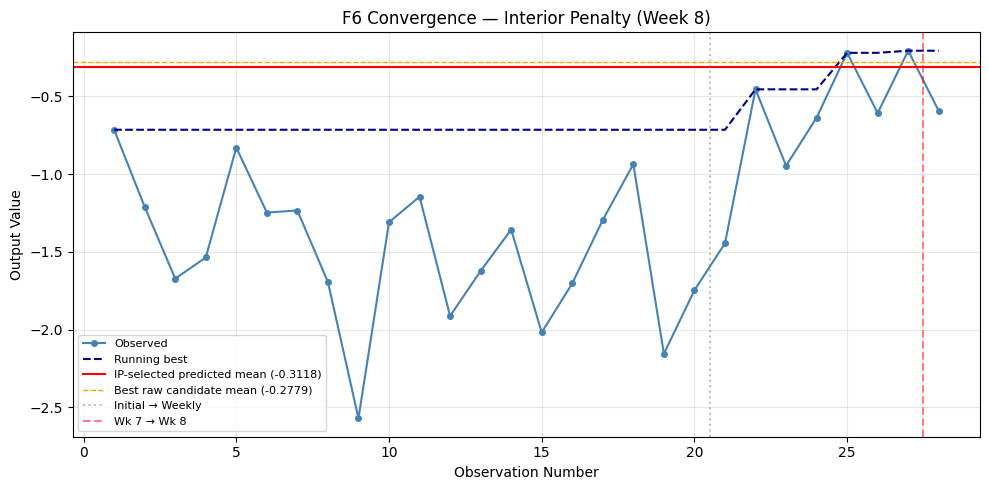

⚠ IP changed selection: raw best = C4 (mean=-0.277913), IP selected = C3 (mean=-0.311843)


In [12]:
# ── Interior Penalty: Convergence Plot ──
running_best = np.maximum.accumulate(y_raw)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_raw) + 1), y_raw, 'o-', color='steelblue', markersize=4, label='Observed')
plt.plot(range(1, len(running_best) + 1), running_best, '--', color='darkblue',
         linewidth=1.5, label='Running best')

# IP-selected predicted mean
ip_pred = pred_means[best_ip_idx]
plt.axhline(ip_pred, color='red', linestyle='-', linewidth=1.5,
            label=f'IP-selected predicted mean ({ip_pred:.4f})')

# Raw best candidate mean (if different from IP selection)
raw_best_idx = int(np.argmax(pred_means))
if raw_best_idx != best_ip_idx:
    raw_best_pred = pred_means[raw_best_idx]
    plt.axhline(raw_best_pred, color='orange', linestyle='--', linewidth=1.0,
                label=f'Best raw candidate mean ({raw_best_pred:.4f})')

plt.axvline(x=20.5, color="gray", linestyle=":", alpha=0.5, label="Initial → Weekly")
plt.axvline(x=27.5, color="red", linestyle="--", alpha=0.5, label="Wk 7 → Wk 8")
plt.xlabel("Observation Number")
plt.ylabel("Output Value")
plt.title("F6 Convergence — Interior Penalty (Week 8)")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison
if raw_best_idx != best_ip_idx:
    print(f"⚠ IP changed selection: raw best = C{raw_best_idx+1} "
          f"(mean={pred_means[raw_best_idx]:.6f}), "
          f"IP selected = C{best_ip_idx+1} (mean={pred_means[best_ip_idx]:.6f})")
else:
    print(f"✓ IP confirmed raw-best candidate #{best_ip_idx+1}")

In [13]:
# ── Interior Penalty: Submission Query ──
submission_point_ip = np.clip(ip_point, 0.0, 0.999999)
query_ip = "-".join(f"{v:.6f}" for v in submission_point_ip)

# Strict validation
assert re.match(r'^(0\.\d{6}-){4}0\.\d{6}$', query_ip), f"Format mismatch: {query_ip}"
assert np.all(submission_point_ip >= 0.01), "Some values below 0.01!"
assert submission_point_ip[4] >= 0.10, f"x4 (milk) = {submission_point_ip[4]:.6f} below 0.10!"

print("=" * 60)
print("WEEK 8 SUBMISSION QUERY — F6 (Interior Penalty)")
print("=" * 60)
print(f"\n  {query_ip}\n")
print("=" * 60)

print(f"\n  STEEPNESS = {STEEPNESS}")
print(f"  FLOOR     = {FLOOR}")
print(f"  Interior weight: {interior_weight[best_ip_idx]:.6f}")
print(f"  Combined score:  {combined_score[best_ip_idx]} / {2 * Q}")
print(f"  Posterior mean:   {pred_means[best_ip_idx]:.6f}")

# Compare with raw best
raw_best_idx = int(np.argmax(pred_means))
if raw_best_idx != best_ip_idx:
    print(f"\n  ⚠ Penalty CHANGED selection:")
    raw_pt = candidates[raw_best_idx].cpu().numpy()
    print(f"    Raw best:     C{raw_best_idx+1} → [{', '.join(f'{v:.6f}' for v in raw_pt)}]")
    print(f"    IP-selected:  C{best_ip_idx+1} → [{', '.join(f'{v:.6f}' for v in ip_point)}]")
else:
    print(f"\n  ✓ Penalty confirmed raw-best candidate #{best_ip_idx + 1}")

# Per-ingredient breakdown
print(f"\nPer-ingredient breakdown:")
for i, (name, val) in enumerate(zip(ingredient_names, submission_point_ip)):
    bound = '≥ 0.10' if i == 4 else '≥ 0.01'
    status = '✓' if (val >= 0.10 if i == 4 else val >= 0.01) else '✗'
    print(f"  x{i} ({name:>6s}) = {val:.6f}  {status} {bound}")

# Duplicate check against base NEI submission
if query_ip == query_nei:
    print(f"\n⚠ IP submission identical to base NEI — penalty had no effect")
else:
    print(f"\n✓ IP and base NEI submissions differ")
print("=" * 60)

WEEK 8 SUBMISSION QUERY — F6 (Interior Penalty)

  0.402330-0.330813-0.573610-0.733655-0.100000


  STEEPNESS = 1.0
  FLOOR     = 0.01
  Interior weight: 0.043345
  Combined score:  5 / 8
  Posterior mean:   -0.311843

  ⚠ Penalty CHANGED selection:
    Raw best:     C4 → [0.477082, 0.396610, 0.549288, 0.732679, 0.100000]
    IP-selected:  C3 → [0.402330, 0.330813, 0.573610, 0.733655, 0.100000]

Per-ingredient breakdown:
  x0 ( flour) = 0.402330  ✓ ≥ 0.01
  x1 ( sugar) = 0.330813  ✓ ≥ 0.01
  x2 (  eggs) = 0.573610  ✓ ≥ 0.01
  x3 (butter) = 0.733655  ✓ ≥ 0.01
  x4 (  milk) = 0.100000  ✓ ≥ 0.10

✓ IP and base NEI submissions differ
